In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("database_gEEN.csv")

def strip_units(x):
    if isinstance(x, str):
        x = x.replace("pS", "").replace("nS", "").replace("uS", "")
        x = x.replace("mV", "").replace("ms", "")
        x = x.replace(" ", "")
        try:
            return float(x)
        except:
            return np.nan
    return x

for col in ["coh","gEEN","dt", "dt1", "dt2", "peak1", "peak2"]:
    df[col] = df[col].apply(strip_units)

numeric_cols = ["coh","gEEN","acc","dt1","dt2","dt","peak1","peak2"]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df.head()


,coh,gEIN,gEEN,gIE,acc,dt1,dt2,dt,peak1,peak2,noise_E,noise_I,seed
0,12.8,0.13,0.165,1.3,2,1678.0,NaN,1678.0,32.736166,5.699088,2.4,2.4,A01
1,12.8,0.13,0.165,1.3,2,1628.9,NaN,1628.9,34.546092,3.787120,2.4,2.4,A01
2,12.8,0.13,0.165,1.3,2,1678.0,NaN,1678.0,32.736166,5.699088,2.4,2.4,A01
3,12.8,0.13,0.165,1.3,2,1678.0,NaN,1678.0,32.736166,5.699088,2.4,2.4,A01
4,12.8,0.13,0.165,1.3,2,1628.9,NaN,1628.9,34.546092,3.787120,2.4,2.4,A01


In [2]:
# Automatically detect gEEN values
gEEN_values = sorted(df["gEEN"].dropna().unique())

# Create a perceptually uniform color palette (no overlapping colors)
import numpy as np
import matplotlib.pyplot as plt

palette = plt.cm.viridis(np.linspace(0, 1, len(gEEN_values)))
gEEN_color_map = dict(zip(gEEN_values, palette))

gEEN_color_map


{np.float64(0.164): array([0.267004, 0.004874, 0.329415, 1.      ]),
 np.float64(0.165): array([0.993248, 0.906157, 0.143936, 1.      ])}

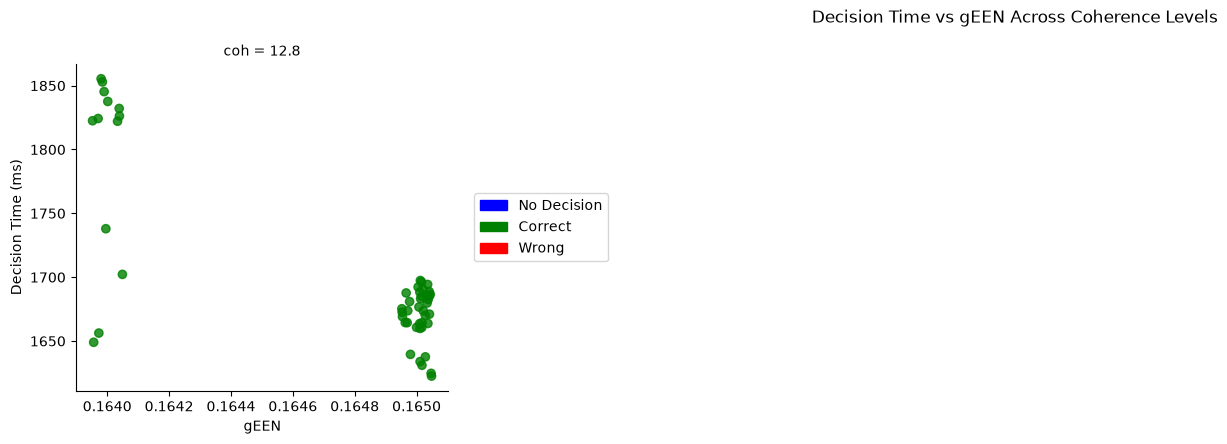

In [3]:
df_plot = df.copy()
df_plot["dt"] = df_plot["dt"].fillna(0)

color_map = {0: "blue", 1: "red", 2: "green"}
df_plot["color"] = df_plot["acc"].map(color_map)

g = sns.FacetGrid(
    df_plot,
    col="coh",
    col_wrap=5,
    height=4,
    sharex=True,
    sharey=True
)

g.map_dataframe(
    lambda data, **kwargs: plt.scatter(
        data["gEEN"] + np.random.uniform(-0.00005, 0.00005, size=len(data)),
        data["dt"]  + np.random.uniform(-20, 20, size=len(data)),
        c=data["color"],
        alpha=0.8
    )
)

g.set_axis_labels("gEEN", "Decision Time (ms)")
g.fig.suptitle("Decision Time vs gEEN Across Coherence Levels", y=1.05)

import matplotlib.patches as mpatches
legend_handles = [
    mpatches.Patch(color="blue", label="No Decision"),
    mpatches.Patch(color="green", label="Correct"),
    mpatches.Patch(color="red", label="Wrong")
]
plt.legend(handles=legend_handles, bbox_to_anchor=(1.05, 0.5), loc="center left")

plt.show()


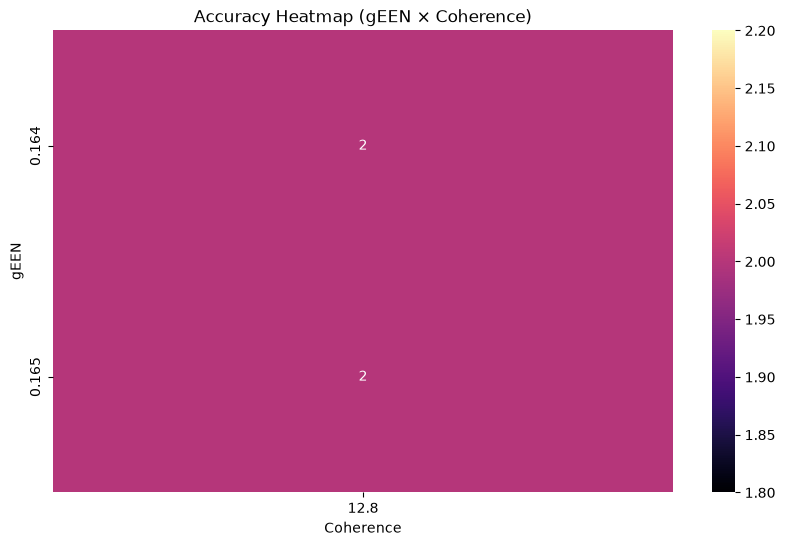

In [4]:
pivot = df.pivot_table(values="acc", index="gEEN", columns="coh", aggfunc="mean")

plt.figure(figsize=(10,6))
sns.heatmap(pivot, annot=True, cmap="magma")
plt.title("Accuracy Heatmap (gEEN × Coherence)")
plt.xlabel("Coherence")
plt.ylabel("gEEN")
plt.show()


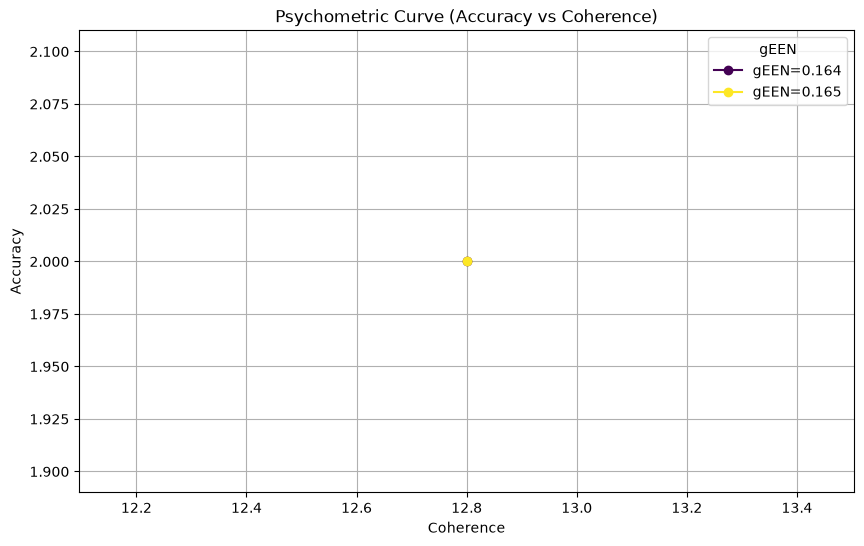

In [5]:
plt.figure(figsize=(10,6))

for g in gEEN_values:
    subset = df[df["gEEN"] == g]
    grouped = subset.groupby("coh")["acc"].mean()
    plt.plot(grouped.index, grouped.values, marker="o",
             label=f"gEEN={g}", color=gEEN_color_map[g])

plt.xlabel("Coherence")
plt.ylabel("Accuracy")
plt.title("Psychometric Curve (Accuracy vs Coherence)")
plt.legend(title="gEEN")
plt.grid(True)
plt.show()


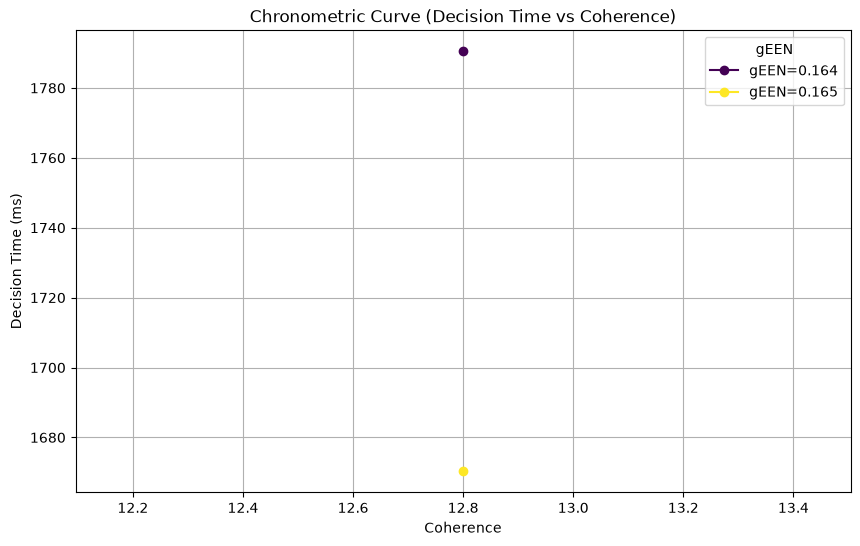

In [6]:
plt.figure(figsize=(10,6))

for g in gEEN_values:
    subset = df[df["gEEN"] == g]
    grouped = subset.groupby("coh")["dt"].mean()
    plt.plot(grouped.index, grouped.values, marker="o",
             label=f"gEEN={g}", color=gEEN_color_map[g])

plt.xlabel("Coherence")
plt.ylabel("Decision Time (ms)")
plt.title("Chronometric Curve (Decision Time vs Coherence)")
plt.legend(title="gEEN")
plt.grid(True)
plt.show()


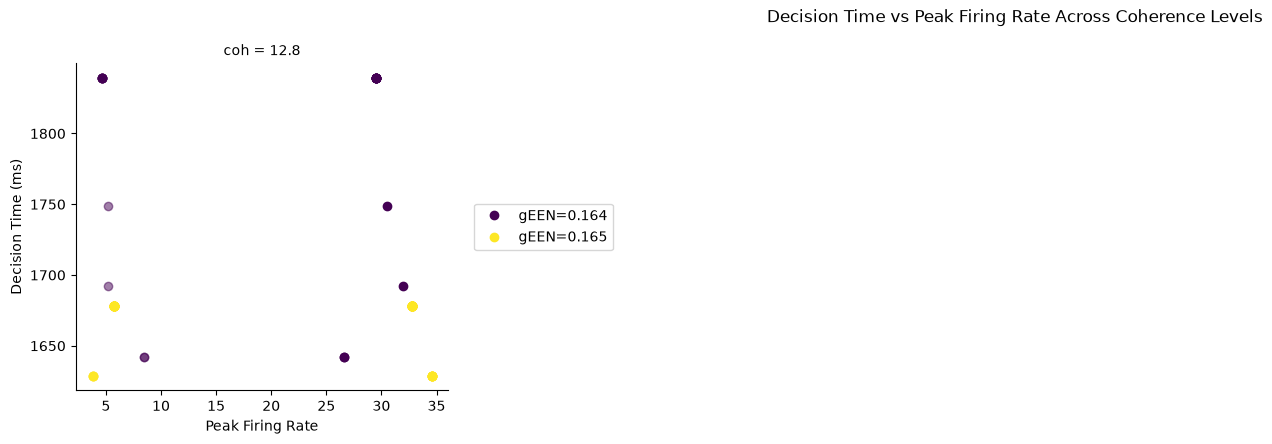

In [7]:
# Create panelled grid by coherence
g = sns.FacetGrid(
    df,
    col="coh",
    col_wrap=5,
    height=4,
    sharex=True,
    sharey=True
)

def scatter_peaks(data, color_map=None, **kwargs):
    for gEEN in data["gEEN"].unique():
        subset = data[data["gEEN"] == gEEN]

        # Stimulated population (peak1)
        plt.scatter(
            subset["peak1"],
            subset["dt"],
            color=color_map[gEEN],
            alpha=1,
            label=f"Stim Pop (gEEN={gEEN})"
        )

        # Non-stimulated population (peak2)
        plt.scatter(
            subset["peak2"],
            subset["dt"],
            color=color_map[gEEN],
            alpha=0.5,
            label=f"Non-Stim Pop (gEEN={gEEN})"
        )

# Map to FacetGrid
g.map_dataframe(scatter_peaks, color_map=gEEN_color_map)

g.set_axis_labels("Peak Firing Rate", "Decision Time (ms)")
g.fig.suptitle("Decision Time vs Peak Firing Rate Across Coherence Levels", y=1.05)

# Legend outside
handles = []
for gEEN, col in gEEN_color_map.items():
    handles.append(
        plt.Line2D([0], [0], marker='o', color=col, label=f"gEEN={gEEN}", linestyle='')
    )

plt.legend(handles=handles, bbox_to_anchor=(1.05, 0.5), loc="center left")
plt.show()

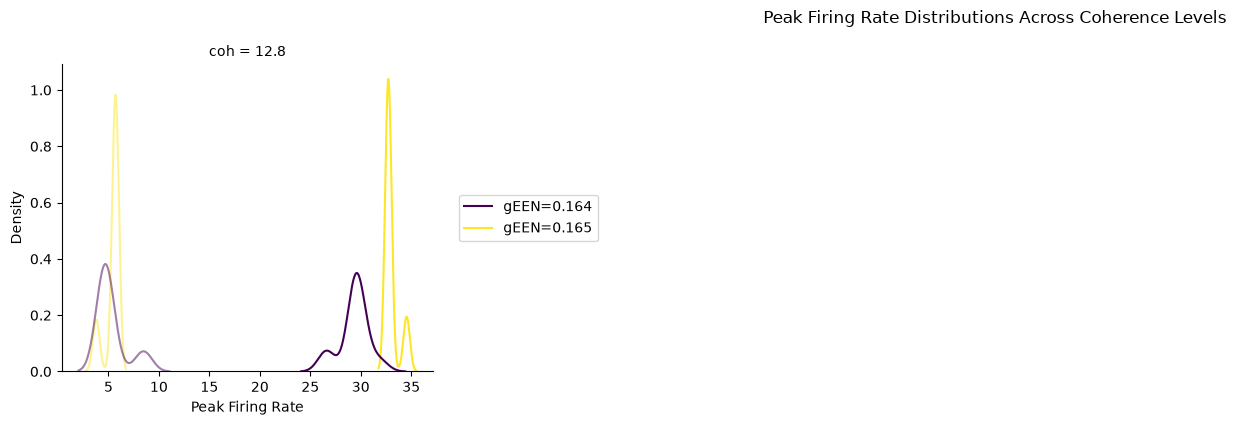

In [8]:
g = sns.FacetGrid(
    df,
    col="coh",
    col_wrap=5,
    height=4,
    sharex=True,
    sharey=True
)

def kde_peaks(data, color_map=None, **kwargs):
    for gEEN in data["gEEN"].unique():
        subset = data[data["gEEN"] == gEEN]

        sns.kdeplot(
            subset["peak1"],
            color=color_map[gEEN],
            linewidth=1.5,
            alpha=1,
            label=f"Stim Pop (gEEN={gEEN})"
        )

        sns.kdeplot(
            subset["peak2"],
            color=color_map[gEEN],
            linewidth=1.5,
            alpha=0.5,
            label=f"Non-Stim Pop (gEEN={gEEN})"
        )

g.map_dataframe(kde_peaks, color_map=gEEN_color_map)

g.set_axis_labels("Peak Firing Rate", "Density")
g.fig.suptitle("Peak Firing Rate Distributions Across Coherence Levels", y=1.05)

# Legend outside
handles = []
for gEEN, col in gEEN_color_map.items():
    handles.append(
        plt.Line2D([0], [0], color=col, label=f"gEEN={gEEN}")
    )

plt.legend(handles=handles, bbox_to_anchor=(1.05, 0.5), loc="center left")
plt.show()